# Agentes de busquedas con langgraph


In [2]:
%pip install -U -q langchain==1.3.4
%pip install -U -q langgraph==1.2.4
%pip install -U -q langchain-google-genai==4.2.4
%pip install -U -q langchain-community==0.4.2
%pip install -U -q langchain-tavily==0.2.18
%pip install -U -q arxiv==4.0.0

In [3]:
from langchain_google_genai import ChatGoogleGenerativeAI
from google.colab import userdata

# Cofiguración de las apis
api_key = userdata.get('Google_api')
api_key_tavily = userdata.get('Tavily')

In [4]:
# Configuración del llm
llm = ChatGoogleGenerativeAI(model='gemini-2.5-flash', temperature=0.5, api_key=api_key)

In [5]:
# Prueba del llm que funciona correctamente
response = llm.invoke('Cuándo arranca el mundial')
print(response.content)

El próximo Mundial de fútbol masculino (FIFA World Cup) arrancará el **11 de junio de 2026**.

Se celebrará en Estados Unidos, Canadá y México, y la final está prevista para el 19 de julio de 2026.


# Creación de las Herramientas para los agentes

In [6]:
from langchain_tavily import TavilySearch
from langchain_core.tools import tool
import requests

In [7]:
import arxiv

print(arxiv.__version__)

4.0.0


In [9]:
# Herramienta Articulos cientificos
from langchain_core.tools import tool
import arxiv

@tool
def buscar_arxiv(query: str) -> str:
    """
    Busca artículos cientificos en arXiv.
    """
    try:
        # Crear cliente
        client = arxiv.Client()

        # Configurar búsqueda
        search = arxiv.Search(
            query=query,
            max_results=3,
            sort_by=arxiv.SortCriterion.Relevance
        )

        # Obtener resultados - FORMA CORRECTA
        resultados = []

        for paper in client.results(search):  # Usar client.results()
            # Limpiar resumen
            abstract = paper.summary.replace('\n', ' ').strip()
            if len(abstract) > 300:
                abstract = abstract[:300] + "..."

            resultados.append(
                f"""**{paper.title}**
                  Año: {paper.published.year}
                  Autores: {', '.join(a.name for a in paper.authors[:3])}{', ...' if len(paper.authors) > 3 else ''}
                  Resumen: {abstract}
                  URL: {paper.entry_id}
                  """
            )

        if not resultados:
            return f"No se encontraron artículos en arXiv para: '{query}'"

        return "\n---\n".join(resultados)

    except Exception as e:
        return f"Error en búsqueda de arXiv: {str(e)}"

In [10]:
# prueba del funcionamiento de la herramienta n1
resultado = buscar_arxiv.invoke({"query": "machine learning"})
print(resultado)

**Changing Data Sources in the Age of Machine Learning for Official Statistics**
                  Año: 2023
                  Autores: Cedric De Boom, Michael Reusens
                  Resumen: Data science has become increasingly essential for the production of official statistics, as it enables the automated collection, processing, and analysis of large amounts of data. With such data science practices in place, it enables more timely, more insightful and more flexible reporting. However...
                  URL: http://arxiv.org/abs/2306.04338v1
                  
---
**DOME: Recommendations for supervised machine learning validation in biology**
                  Año: 2020
                  Autores: Ian Walsh, Dmytro Fishman, Dario Garcia-Gasulla, ...
                  Resumen: Modern biology frequently relies on machine learning to provide predictions and improve decision processes. There have been recent calls for more scrutiny on machine learning performance and possible limita

In [11]:
# Herramienta Busqueda en la web
from langchain_tavily import TavilySearch

tavily_tool = TavilySearch(
    tavily_api_key=api_key_tavily,
    max_results=3,
    search_depth='advanced',
    max_tokens=1000
)

In [12]:
# prueba del funcionamiento herramienta n2
respuesta = tavily_tool.invoke('Dime el impacto de la inteligencia artificial en la Educación')

texto = "\n".join(
    item["content"]
    for item in respuesta["results"]
)

print(texto)

La inteligencia artificial en la educación contribuye al avance de cada estudiante a su ritmo, así como al trabajo en áreas específicas. Especialmente, en aquellas en las que se encuentran en proceso y aún son deficitarias.

Estas tareas realizadas por la inteligencia artificial optimizan los tiempos del docente (tan valorados y ansiados). En consecuencia, pueden redirigir ese tiempo al desarrollo de propuestas más interactivas, centradas en la discusión y en la generación de procesos reflexivos, y de construcción individual y colectiva. [...] Posicionados desde el pensar sobre los beneficios y las oportunidades que la inteligencia artificial en la educación brinda, es posible identificar la personalización de la enseñanza como un elemento que se ve potenciado.

La inteligencia artificial tiene la capacidad de procesar enormes cantidades de datos sobre el desempeño y las preferencias de nuestros estudiantes y, por tanto, puede generar respuestas adaptativas a estos niveles. Eso posibil

#Creación de los agente

In [13]:
from typing import TypedDict

In [14]:
# Estado compartido para los grafos
class AgentState(TypedDict):
  user_query: str
  web_answer: str
  scientific_answer: str
  final_answer: str

In [15]:
# creación del agente
from langchain.agents import create_agent

In [16]:
def funcion_agente_web(state: AgentState) -> dict:
  """
  Función que ejecuta un agente al estilo React que realiza un búsqueda
  en la web sobre un término espefico.

  Está función toma el estado actual del agente (que contiene la pregunta del usuario) y
  crea un agente utilizando Gemini y la herramienta Tavily, y retorna la respuesta del agente.

  Args:
    state(AgentState): un diccionario que contiene la pregunta del usuario y la respuesta del agente.

  Returns:
    str: La respuesta del agente.
  """
  system_prompt = """
  Actúa como un asistente útil y especializado en investigación para responder la consulta del usuario.
  -tavily_tool : realiza busqueda en la web y retorna los resultados.
  Siempre que el usuario pregunte sobre un tema especifico:
  1. Analiza los resultados.
  2. Devuelve una respuesta clara.
  3. Incluye enlaces de las fuentes utilizadas.
  """

  state = state['user_query']

  agente_web = create_agent(
      model=llm,
      system_prompt=system_prompt,
      tools=[tavily_tool]
  )

  resultado = agente_web.invoke({
      'messages':[('user', state)]
  })

  ultimo_mensaje = resultado["messages"][-1]

  if isinstance(ultimo_mensaje.content, str):
    respuesta_final = ultimo_mensaje.content

  elif isinstance(ultimo_mensaje.content, list):
      textos = []

      for bloque in ultimo_mensaje.content:
        if isinstance(bloque, dict):
            textos.append(bloque.get("text", ""))

      respuesta_final = "\n".join(textos)

  else:
      respuesta_final = str(ultimo_mensaje.content)

  return {"web_answer": respuesta_final}

In [17]:
def funcion_agente_cientifico(state: AgentState) -> dict:
  """
  Función que ejecuta un agente al estilo React que realiza un búsqueda
  en la arvix sobre un término espefico o cientifico.

  Esta función toma el estado actual del agente (que contiene la pregunta del usuario) y
  crea un agente utilizando Gemini y la herramienta Arxiv, y retorna la respuesta del agente.

  Args:
    state(AgentState): un diccionario que contiene la pregunta del usuario y la respuesta del agente.

  Returns:
    str: La respuesta del agente.
  """
  system_prompt = """
  Actúa como un asistente útil y especializado en investigación.
  -buscar_arxiv : realiza busqueda en la web y retorna los resultados.
  cuando el usuario pregunte sobre un tema especifico:
  1. Usa la herramienta buscar_articulos
  2. Analiza los resultados.
  3. Devuelve una respuesta clara.
  4. Incluye enlaces de las fuentes utilizadas.
  """

  state = state['user_query']

  agente_cientifico = create_agent(
      model=llm,
      tools=[buscar_arxiv],
      system_prompt=system_prompt
  )

  resultado = agente_cientifico.invoke({
      'messages':[('user', state)]
  })

  ultimo_mensaje = resultado["messages"][-1]

  if isinstance(ultimo_mensaje.content, str):
      respuesta_final = ultimo_mensaje.content

  elif isinstance(ultimo_mensaje.content, list):
      textos = []

      for bloque in ultimo_mensaje.content:
          if isinstance(bloque, dict):
              textos.append(bloque.get("text", ""))

      respuesta_final = "\n".join(textos)

  else:
      respuesta_final = str(ultimo_mensaje.content)

  return {"scientific_answer": respuesta_final}

In [18]:
def supervisor_node(state: AgentState) -> dict:
  """
  Combina los resultados de los agentes web y científico en un solo mensaje o sea una respuestas final.

  Args:
    state(AgentState): El estado actual del agente, que contiene web_aswer y scientific_answer.

  Returns:
    str: Un diccionario que contiene la respueta final combinada y formateada.
  """
  web_result = state.get('web_answer','No se realizó ninguna busqueda en la web.')
  scientific_result = state.get('scientific_answer', 'No se realizó ninguna busqueda cientifica.')

  final_answer = "## Resultados combinados de busqueda\n\n"
  final_answer += '## Busqueda en la web\n\n'
  final_answer += web_result
  final_answer += '\n\n'
  final_answer += '## Busqueda cientifica\n\n'
  final_answer += scientific_result

  return {'final_answer': final_answer}

In [19]:
def router_agent(state: AgentState) -> dict:

  router_prompt = """
  Eres un agente ruteador. Tu tarea es decidir cuál agente es más apropiado
  para responder la pregunta del usuario.

  Pregunta del usuario: {user_query}

  Puedes elegir entre las siguientes opciones:
  - web_search: Usa esta opción si la pregunta requiere una búsqueda general en internet.
  - scientific_search: Usa esta opción si la pregunta requiere artículos científicos.

  Responde ÚNICAMENTE con el nombre de la opción (web_search o scientific_search).
  """

  router_agent_instance = create_agent(
      model=llm,
      tools=[],
      system_prompt=router_prompt
  )

  response = router_agent_instance.invoke({
      "messages": [("user", state["user_query"])]
  })

  decision = response["messages"][-1].content

  if decision == "web_search":
      return {"router_decision": "web_search"}
  elif decision == "scientific_search":
      return {"router_decision": "scientific_search"}

  # Por defecto, usamos web_search
  return {"router_decision": "web_search"}

# Construcción del Grafo con LangGraph

In [20]:
from langgraph.graph import StateGraph, START, END

In [21]:
workflow = StateGraph(AgentState)

In [25]:
workflow.add_node("router", router_agent)
workflow.add_node("web_search", funcion_agente_web)
workflow.add_node("scientific_search", funcion_agente_cientifico)
workflow.add_node("supervisor", supervisor_node)

workflow.add_edge(START, "router")
workflow.add_conditional_edges(
    "router",
    lambda state: state["router_decision"],
    {
        "web_search": "web_search",
        "scientific_search": "scientific_search",
    }
)
workflow.add_edge("web_search", "supervisor")
workflow.add_edge("scientific_search", "supervisor")
workflow.add_edge("supervisor", END)

app = workflow.compile()

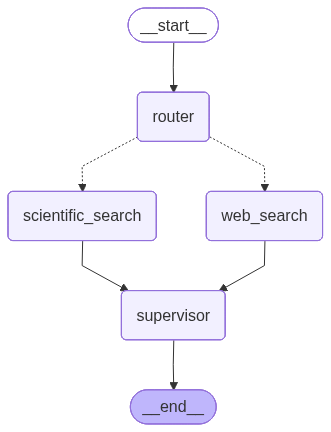

In [26]:
from IPython.display import display, Image
Image(app.get_graph().draw_mermaid_png())

In [27]:
resultado = app.invoke({
    "user_query": "Cuál es el impacto de la IA en la Educación? Usa solo fuentes web"
})

print(resultado['final_answer'])

## Resultados combinados de busqueda

## Busqueda en la web

La Inteligencia Artificial (IA) está generando un impacto profundo y multidimensional en el ámbito educativo, transformando la experiencia de aprendizaje y el rol de los docentes.

**Impactos Positivos de la IA en la Educación:**

*   **Personalización del Aprendizaje:** La IA permite adaptar el contenido, la dificultad y el formato de presentación según el progreso, las habilidades y las preferencias de cada estudiante. Esto mejora el rendimiento académico y aumenta la motivación al ofrecer una experiencia educativa a medida [1, 3].
*   **Automatización de Tareas Administrativas:** Ayuda a las instituciones educativas a automatizar tareas repetitivas como la gestión de registros de estudiantes, la programación de clases y la evaluación de exámenes básicos. Esto libera tiempo para los profesores, permitiéndoles enfocarse en la enseñanza personalizada y el desarrollo de pensamiento crítico [1, 2].
*   **Democratización y Acces

In [28]:
resultado = app.invoke({
   "user_query": "What is the impact of AI on education? Use only scientific sources."
})

print(resultado["final_answer"])

## Resultados combinados de busqueda

## Busqueda en la web

No se realizó ninguna busqueda en la web.

## Busqueda cientifica

La inteligencia artificial (IA) está transformando la educación de diversas maneras, abordando la necesidad de modernización y ofreciendo nuevas herramientas para la investigación y el aprendizaje.

Un estudio reciente, "Need of AI in Modern Education: in the Eyes of Explainable AI (xAI)" (2024), destaca la indispensabilidad de la IA en la educación moderna. Sin embargo, también señala los desafíos inherentes a la complejidad de la IA, lo que dificulta la comprensión y resolución de problemas. La investigación también explora cómo la IA puede influir en las decisiones educativas, especialmente en el contexto de la influencia del ingreso de los padres en la educación de los hijos.

Además, la IA generativa está demostrando ser una herramienta valiosa en la investigación y la educación, como se explora en "Exploring utilization of generative AI for research and 

# Interfaz gráfica

In [29]:
import gradio as gr

def run_graph(user_query):
  """Ejecuta el LangGraph con la pregunta del usuario y devulve la respuesta final."""

  result = app.invoke({"user_query": user_query})
  return result["final_answer"]

iface = gr.Interface(
    fn=run_graph,
    inputs=gr.Textbox(label="Escribe tu pregunta:"),
    outputs=gr.Markdown(label="Respuesta final"),
    title="Agente de Búsqueda Inteligente",
    description="Haz una pregunta y obtén una respuesta usando fuentes web o científicas."
)

iface.launch()

It looks like you are running Gradio on a hosted Jupyter notebook, which requires `share=True`. Automatically setting `share=True` (you can turn this off by setting `share=False` in `launch()` explicitly).

Colab notebook detected. To show errors in colab notebook, set debug=True in launch()
* Running on public URL: https://3b47ad4213c1403c65.gradio.live

This share link expires in 1 week. For free permanent hosting and GPU upgrades, run `gradio deploy` from the terminal in the working directory to deploy to Hugging Face Spaces (https://huggingface.co/spaces)
